# Model Interpretation & Business Insights

The Logistic Regression model provides insight into the factors associated with customer churn.

This analysis focuses on identifying key churn drivers and translating model results into actionable business recommendations.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv(
    "../data/processed/customer_churn_encoded.csv"
)

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
scaler = StandardScaler()

num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)


In [5]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Feature Importance

Logistic Regression coefficients indicate whether a feature increases or decreases the likelihood of customer churn.

Positive coefficients are associated with higher churn risk, while negative coefficients are associated with customer retention.

In [6]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients.head()

,Feature,Coefficient
0,SeniorCitizen,0.195363
1,tenure,-1.355817
2,MonthlyCharges,-0.445174
3,TotalCharges,0.641811
4,gender_Male,-0.025018


In [7]:
top_positive = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

top_positive.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,1.121685
3,TotalCharges,0.641811
28,PaymentMethod_Electronic check,0.386286
21,StreamingTV_Yes,0.374880
9,MultipleLines_Yes,0.362680
23,StreamingMovies_Yes,0.347601
26,PaperlessBilling_Yes,0.290723
0,SeniorCitizen,0.195363
29,PaymentMethod_Mailed check,0.076969
17,DeviceProtection_Yes,0.073764


In [8]:
top_negative = coefficients.sort_values(
    by="Coefficient",
    ascending=True
)

top_negative.head(10)

,Feature,Coefficient
1,tenure,-1.355817
25,Contract_Two year,-1.351225
24,Contract_One year,-0.743489
7,PhoneService_Yes,-0.522947
2,MonthlyCharges,-0.445174
13,OnlineSecurity_Yes,-0.370820
19,TechSupport_Yes,-0.329742
6,Dependents_Yes,-0.231842
8,MultipleLines_No phone service,-0.183234
18,TechSupport_No internet service,-0.168056


In [9]:
import matplotlib.pyplot as plt

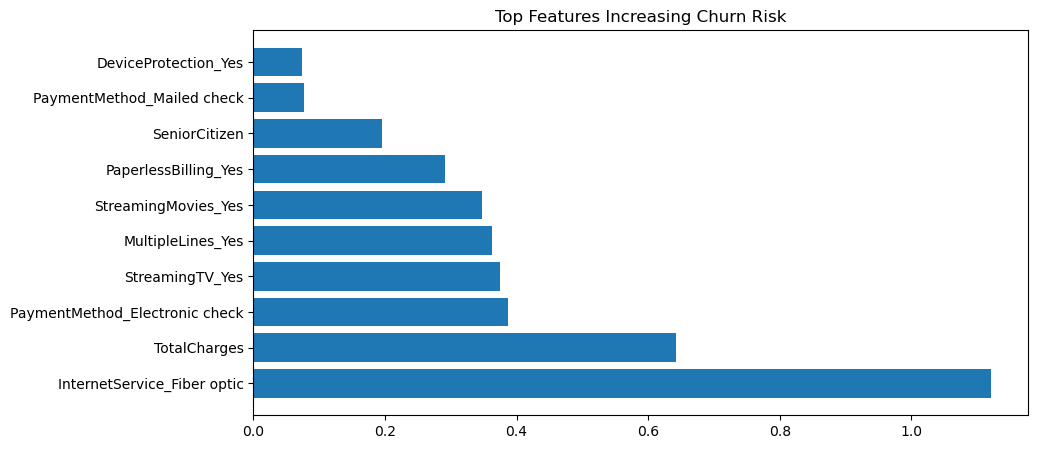

In [10]:
top_10_positive = top_positive.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_10_positive["Feature"],
    top_10_positive["Coefficient"]
)

plt.title("Top Features Increasing Churn Risk")

plt.show()

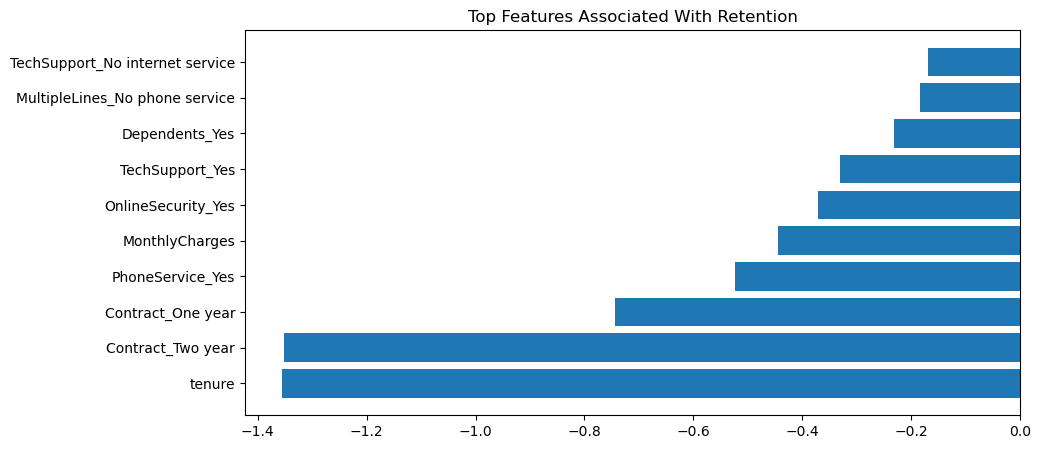

In [11]:
top_10_negative = top_negative.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_10_negative["Feature"],
    top_10_negative["Coefficient"]
)

plt.title("Top Features Associated With Retention")

plt.show()

In [12]:
print(top_positive.head(10))
print("\n")
print(top_negative.head(10))

                           Feature  Coefficient
10     InternetService_Fiber optic     1.121685
3                     TotalCharges     0.641811
28  PaymentMethod_Electronic check     0.386286
21                 StreamingTV_Yes     0.374880
9                MultipleLines_Yes     0.362680
23             StreamingMovies_Yes     0.347601
26            PaperlessBilling_Yes     0.290723
0                    SeniorCitizen     0.195363
29      PaymentMethod_Mailed check     0.076969
17            DeviceProtection_Yes     0.073764


                            Feature  Coefficient
1                            tenure    -1.355817
25                Contract_Two year    -1.351225
24                Contract_One year    -0.743489
7                  PhoneService_Yes    -0.522947
2                    MonthlyCharges    -0.445174
13               OnlineSecurity_Yes    -0.370820
19                  TechSupport_Yes    -0.329742
6                    Dependents_Yes    -0.231842
8    MultipleLines_No phone s

In [14]:
top_positive.head(10).reset_index(drop=True)

,Feature,Coefficient
0,InternetService_Fiber optic,1.121685
1,TotalCharges,0.641811
2,PaymentMethod_Electronic check,0.386286
3,StreamingTV_Yes,0.374880
4,MultipleLines_Yes,0.362680
5,StreamingMovies_Yes,0.347601
6,PaperlessBilling_Yes,0.290723
7,SeniorCitizen,0.195363
8,PaymentMethod_Mailed check,0.076969
9,DeviceProtection_Yes,0.073764


In [15]:
top_negative.head(10).reset_index(drop=True)

,Feature,Coefficient
0,tenure,-1.355817
1,Contract_Two year,-1.351225
2,Contract_One year,-0.743489
3,PhoneService_Yes,-0.522947
4,MonthlyCharges,-0.445174
5,OnlineSecurity_Yes,-0.370820
6,TechSupport_Yes,-0.329742
7,Dependents_Yes,-0.231842
8,MultipleLines_No phone service,-0.183234
9,TechSupport_No internet service,-0.168056


## Key Findings

- Month-to-month contracts churn way more than 1-2 year contracts — biggest driver in the data
- Churn is highest in the first ~12 months, drops off sharply after that
- No tech support / no online security = higher churn (these customers feel less "locked in")
- Fiber optic customers churn more than DSL — worth digging into separately (pricing? service issues?)
- Long contracts + support add-ons = stickier customers, consistently

## Recommendations

1. Push month-to-month customers toward annual contracts with a discount or incentive — this is the single highest-leverage lever based on the data
2. Build a first-year retention touchpoint (onboarding check-ins, early discount) since churn risk is front-loaded
3. Bundle Tech Support + Online Security into existing plans instead of selling separately — adoption is low and it's tied to retention
4. Look into why fiber customers churn more — could be price complaints or service quality, needs a follow-up not in this dataset
5. Use the model's churn probability score to flag at-risk customers before contract renewal, not after

## Summary

Built a logistic regression model to flag customers likely to churn, using contract, tenure, and service data.

Model results:
- Accuracy: 80.45%
- Precision: 65.05%
- Recall: 57.22%
- F1: 60.88%

Recall is the weaker number here — model misses some actual churners. For a retention use case that's worth flagging, since the cost of missing a churner is usually higher than a false alarm. Contract type and tenure are the strongest signals overall.

Biggest takeaway: churn is concentrated in month-to-month, low-tenure customers — that's where retention spend should go first.